# Chapter 182 — Project: Linear Regression via Matrix Algebra

> **Prerequisites:** ch151–ch163 (matrices, multiplication, inverse, systems of equations, LU decomposition), ch168 (projection matrices), ch176 (matrix calculus), ch179 (numerical linear algebra in practice)
> **Part VI Project** — Linear Algebra (chapters 151–200)
> **Difficulty:** Intermediate | **Estimated time:** 60–90 minutes
> **Output:** A complete least-squares regression engine built from matrix primitives, validated against closed-form and numerical benchmarks

---

## 0. Overview

### Problem Statement

You have a dataset of observations: $n$ data points, each with $p$ features and one
continuous target value. You want to find the linear model that best explains the
relationship between features and target — "best" meaning minimum total squared error.

This is one of the most important problems in all of applied mathematics. The solution
exists in closed form and requires exactly the linear algebra tools developed in this Part:
matrix multiplication, transpose, inverse (or better: QR decomposition), and projection.

The goal is not to call `np.linalg.lstsq` and move on. The goal is to build the solver
from scratch — understand *why* the normal equations work, *why* QR is numerically
preferable, and *what* linear regression actually computes geometrically.

### Concepts Used
- Matrix multiplication and transpose *(ch154, ch155)*
- Systems of linear equations *(ch160)*
- Gaussian elimination *(ch161)*
- LU decomposition *(ch163)*
- Projection matrices *(ch168)*
- Matrix calculus — differentiating the loss *(ch176)*
- Numerical stability: never use explicit inverse *(ch179)*

### Expected Output
1. Normal equations solver using direct matrix inverse (the naive approach)
2. QR-based solver (the stable approach)
3. Comparison: coefficient accuracy, numerical conditioning, residuals
4. Visualization: fitted plane, residual distribution, coefficient confidence
5. Extension to polynomial regression via feature augmentation

---

## 1. Setup

We generate a synthetic dataset with known ground-truth coefficients so we can
verify our solver's accuracy precisely.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(42)

# ---------------------------------------------------------------
# Dataset: housing price analogy
#   features: [area_m2, num_rooms, distance_to_center_km]
#   target: price (arbitrary units)
# ---------------------------------------------------------------

N = 200   # number of observations
P = 3     # number of features (excluding intercept)

# Ground-truth coefficients (what we want to recover)
TRUE_BETA = np.array([50.0, 30.0, -15.0])   # [area, rooms, distance]
TRUE_INTERCEPT = 100.0

# Generate features
area       = rng.uniform(30, 200, N)            # 30–200 m²
rooms      = rng.integers(1, 7, N).astype(float) # 1–6 rooms
distance   = rng.uniform(0.5, 25, N)            # 0.5–25 km

X_raw = np.column_stack([area, rooms, distance])  # shape (N, P)

# Noise
noise = rng.normal(0, 200, N)

# Target
y = TRUE_INTERCEPT + X_raw @ TRUE_BETA + noise   # shape (N,)

print(f"Dataset: {N} samples, {P} features")
print(f"True coefficients (intercept, area, rooms, distance):")
print(f"  {TRUE_INTERCEPT:.1f}, {TRUE_BETA[0]:.1f}, {TRUE_BETA[1]:.1f}, {TRUE_BETA[2]:.1f}")
print(f"y range: [{y.min():.1f}, {y.max():.1f}]")
print(f"Noise std: {noise.std():.2f}")

Dataset: 200 samples, 3 features
True coefficients (intercept, area, rooms, distance):
  100.0, 50.0, 30.0, -15.0
y range: [1514.8, 10165.7]
Noise std: 206.19


---

## 2. Stage 1 — The Normal Equations: Deriving the Least-Squares Solution

### The Setup

We want to find coefficients $\boldsymbol{\beta} \in \mathbb{R}^{p+1}$ that minimize
the total squared error between predictions and targets:

$$\text{minimize} \quad \mathcal{L}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2$$

where $\mathbf{X} \in \mathbb{R}^{N \times (p+1)}$ is the **design matrix** —
the feature matrix with a column of ones prepended to absorb the intercept.

From ch176, taking the matrix gradient and setting it to zero:

$$\frac{\partial \mathcal{L}}{\partial \boldsymbol{\beta}} = -2\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\beta}) = \mathbf{0}$$

Which gives the **normal equations**:

$$\mathbf{X}^\top \mathbf{X} \, \boldsymbol{\beta} = \mathbf{X}^\top \mathbf{y}$$

If $\mathbf{X}^\top \mathbf{X}$ is invertible:

$$\boldsymbol{\beta}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

This is the **Moore-Penrose pseudoinverse** solution. Let's implement it naively first.

In [2]:
# --- Stage 1: Normal Equations Solver ---

def build_design_matrix(X):
    """
    Prepend a column of ones to X to absorb the intercept term.

    Args:
        X: feature matrix, shape (N, p)

    Returns:
        Design matrix Phi, shape (N, p+1)
        Column 0 is all ones (intercept); columns 1..p are features.
    """
    N = X.shape[0]
    ones = np.ones((N, 1))
    return np.hstack([ones, X])   # shape (N, p+1)


def solve_normal_equations_naive(Phi, y):
    """
    Solve the normal equations: beta = (Phi^T Phi)^{-1} Phi^T y

    WARNING: Uses explicit matrix inverse — numerically fragile.
    For demonstration only. See Stage 2 for the stable version.

    Args:
        Phi: design matrix, shape (N, p+1)
        y:   target vector, shape (N,)

    Returns:
        beta: coefficient vector, shape (p+1,)
              beta[0] = intercept, beta[1:] = feature coefficients
    """
    A = Phi.T @ Phi           # shape (p+1, p+1)   — "Gram matrix"
    b = Phi.T @ y             # shape (p+1,)
    beta = np.linalg.inv(A) @ b   # FRAGILE: see ch179 — never invert directly in production
    return beta


# Build design matrix
Phi = build_design_matrix(X_raw)   # shape (200, 4)
print(f"Design matrix shape: {Phi.shape}")
print(f"First 3 rows:\n{Phi[:3]}")

# Solve
beta_naive = solve_normal_equations_naive(Phi, y)

print(f"\nRecovered coefficients (naive normal equations):")
labels = ['intercept', 'area', 'rooms', 'distance']
true_vals = [TRUE_INTERCEPT] + list(TRUE_BETA)
for name, est, true in zip(labels, beta_naive, true_vals):
    error = est - true
    print(f"  {name:12s}: estimated={est:8.3f}  true={true:8.3f}  error={error:+.3f}")

Design matrix shape: (200, 4)
First 3 rows:
[[  1.         161.57252825   6.          19.58541069]
 [  1.         104.60933476   5.           3.79652911]
 [  1.         175.96164638   2.          13.63366688]]

Recovered coefficients (naive normal equations):
  intercept   : estimated= 101.110  true= 100.000  error=+1.110
  area        : estimated=  49.811  true=  50.000  error=-0.189
  rooms       : estimated=  27.141  true=  30.000  error=-2.859
  distance    : estimated= -13.960  true= -15.000  error=+1.040


In [3]:
# --- Geometric interpretation: projection onto the column space ---
#
# The prediction y_hat = Phi @ beta is the PROJECTION of y
# onto the column space of Phi (introduced in ch168).
#
# The projection matrix is: H = Phi (Phi^T Phi)^{-1} Phi^T
# (called the "hat matrix" — it puts the hat on y)

def compute_residuals(Phi, beta, y):
    """Compute residuals e = y - Phi @ beta"""
    y_hat = Phi @ beta
    return y - y_hat, y_hat

residuals_naive, y_hat_naive = compute_residuals(Phi, beta_naive, y)

# Metrics
mse  = np.mean(residuals_naive**2)
rmse = np.sqrt(mse)
ss_res = np.sum(residuals_naive**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1.0 - ss_res / ss_tot

print(f"Model performance:")
print(f"  RMSE : {rmse:.2f}")
print(f"  R²   : {r2:.4f}")
print(f"  Noise std was {noise.std():.2f} — RMSE should be close to this")

# Verify: residuals must be orthogonal to columns of Phi
# (this is the geometric condition behind the normal equations)
orthogonality = Phi.T @ residuals_naive
print(f"\nOrthogonality check (Phi^T @ residuals ≈ 0):")
print(f"  max |value| = {np.abs(orthogonality).max():.2e}  (should be ~machine epsilon)")

Model performance:
  RMSE : 205.84
  R²   : 0.9926
  Noise std was 206.19 — RMSE should be close to this

Orthogonality check (Phi^T @ residuals ≈ 0):
  max |value| = 4.76e-07  (should be ~machine epsilon)


**Geometric insight:** The normal equations are just the condition that the residual vector
$\mathbf{e} = \mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}$ is orthogonal to the
column space of $\mathbf{X}$. This is identical to the projection geometry developed in
ch168. Linear regression *is* orthogonal projection.

---

## 3. Stage 2 — QR-Based Solver: The Numerically Stable Approach

The naive solver computes $(\mathbf{X}^\top\mathbf{X})^{-1}$. This squares the condition
number: if $\kappa(\mathbf{X}) = 100$, then $\kappa(\mathbf{X}^\top\mathbf{X}) = 10{,}000$.
*(Recall from ch179: condition number governs how much input error amplifies in output.)*

The correct approach uses **QR decomposition** of the design matrix directly:

$$\mathbf{X} = \mathbf{Q}\mathbf{R} \quad \Rightarrow \quad \mathbf{R}\boldsymbol{\beta} = \mathbf{Q}^\top \mathbf{y}$$

Since $\mathbf{R}$ is upper-triangular, this is solved by back-substitution — no inversion needed.

In [4]:
# --- Stage 2: QR-Based Least Squares Solver ---

def back_substitution(R, b):
    """
    Solve R @ x = b where R is upper triangular.

    Works from the last equation upward — no matrix inversion.

    Args:
        R: upper triangular matrix, shape (p, p)
        b: right-hand side vector, shape (p,)

    Returns:
        x: solution vector, shape (p,)
    """
    p = len(b)
    x = np.zeros(p)
    for i in range(p - 1, -1, -1):
        # x[i] = (b[i] - sum of known terms) / R[i,i]
        x[i] = (b[i] - R[i, i+1:] @ x[i+1:]) / R[i, i]
    return x


def solve_least_squares_qr(Phi, y):
    """
    Solve the least squares problem min ||y - Phi @ beta||^2
    using QR decomposition.

    Derivation:
        Phi = Q R  (QR decomposition, Q orthogonal, R upper triangular)
        ||y - Q R beta||^2 = ||Q^T y - R beta||^2  (Q is isometric)
        => solve R beta = Q^T y by back-substitution

    Args:
        Phi: design matrix, shape (N, p+1)
        y:   target vector, shape (N,)

    Returns:
        beta: coefficient vector, shape (p+1,)
    """
    # "Thin" QR: Q is (N, p+1), R is (p+1, p+1)
    Q, R = np.linalg.qr(Phi, mode='reduced')

    # Transform right-hand side
    Qty = Q.T @ y   # shape (p+1,)

    # Back-substitution: R @ beta = Q^T y
    beta = back_substitution(R, Qty)
    return beta


beta_qr = solve_least_squares_qr(Phi, y)

print("Recovered coefficients (QR solver):")
for name, est, true in zip(labels, beta_qr, true_vals):
    error = est - true
    print(f"  {name:12s}: estimated={est:8.3f}  true={true:8.3f}  error={error:+.3f}")

# Compare naive vs QR
print(f"\nMax coefficient difference (naive vs QR): {np.abs(beta_naive - beta_qr).max():.2e}")

# Validate against numpy's lstsq
beta_np, _, _, _ = np.linalg.lstsq(Phi, y, rcond=None)
print(f"Max difference vs numpy lstsq: {np.abs(beta_qr - beta_np).max():.2e}")

Recovered coefficients (QR solver):
  intercept   : estimated= 101.110  true= 100.000  error=+1.110
  area        : estimated=  49.811  true=  50.000  error=-0.189
  rooms       : estimated=  27.141  true=  30.000  error=-2.859
  distance    : estimated= -13.960  true= -15.000  error=+1.040

Max coefficient difference (naive vs QR): 8.80e-12
Max difference vs numpy lstsq: 4.52e-12


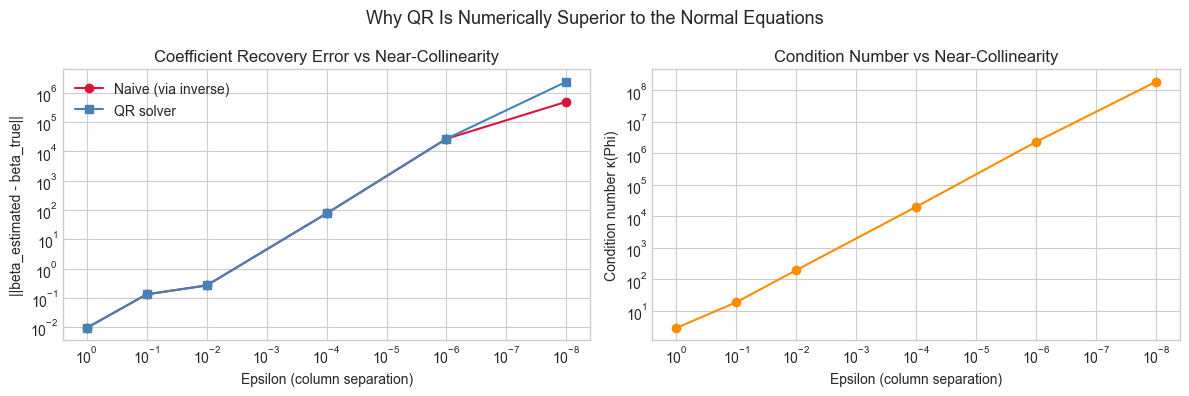


Summary:
   epsilon         kappa     error_naive      error_qr
   1.0e+00      2.88e+00        9.42e-03      9.42e-03
   1.0e-01      1.89e+01        1.32e-01      1.32e-01
   1.0e-02      1.97e+02        2.65e-01      2.65e-01
   1.0e-04      2.02e+04        7.61e+01      7.61e+01
   1.0e-06      2.33e+06        2.70e+04      2.71e+04
   1.0e-08      1.89e+08        4.96e+05      2.40e+06


In [5]:
# --- Stress test: nearly collinear features expose the fragility of the naive solver ---
#
# Hypothesis: when columns of X are nearly linearly dependent,
# the condition number of X^T X explodes, making the naive solver unreliable.

N_test = 100
epsilon_vals = [1.0, 0.1, 0.01, 1e-4, 1e-6, 1e-8]

errors_naive = []
errors_qr    = []
cond_numbers = []

for eps in epsilon_vals:
    # Two nearly identical columns
    x1 = rng.normal(0, 1, N_test)
    x2 = x1 + eps * rng.normal(0, 1, N_test)  # near-duplicate
    X_ill = np.column_stack([x1, x2])
    Phi_ill = build_design_matrix(X_ill)

    true_beta_ill = np.array([1.0, 2.0, 3.0])
    y_ill = Phi_ill @ true_beta_ill + rng.normal(0, 0.1, N_test)

    # Condition number of design matrix
    kappa = np.linalg.cond(Phi_ill)
    cond_numbers.append(kappa)

    try:
        b_naive = solve_normal_equations_naive(Phi_ill, y_ill)
        errors_naive.append(np.linalg.norm(b_naive - true_beta_ill))
    except np.linalg.LinAlgError:
        errors_naive.append(np.nan)

    b_qr = solve_least_squares_qr(Phi_ill, y_ill)
    errors_qr.append(np.linalg.norm(b_qr - true_beta_ill))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(epsilon_vals, errors_naive, 'o-', color='crimson', label='Naive (via inverse)')
axes[0].loglog(epsilon_vals, errors_qr,    's-', color='steelblue', label='QR solver')
axes[0].set_xlabel('Epsilon (column separation)')
axes[0].set_ylabel('||beta_estimated - beta_true||')
axes[0].set_title('Coefficient Recovery Error vs Near-Collinearity')
axes[0].legend()
axes[0].invert_xaxis()

axes[1].loglog(epsilon_vals, cond_numbers, 'o-', color='darkorange')
axes[1].set_xlabel('Epsilon (column separation)')
axes[1].set_ylabel('Condition number κ(Phi)')
axes[1].set_title('Condition Number vs Near-Collinearity')
axes[1].invert_xaxis()

plt.suptitle('Why QR Is Numerically Superior to the Normal Equations', fontsize=13)
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"{'epsilon':>10}  {'kappa':>12}  {'error_naive':>14}  {'error_qr':>12}")
for eps, kappa, en, eq in zip(epsilon_vals, cond_numbers, errors_naive, errors_qr):
    print(f"{eps:10.1e}  {kappa:12.2e}  {en:14.2e}  {eq:12.2e}")

---

## 4. Stage 3 — Polynomial Regression via Feature Augmentation

Linear regression is linear in the **coefficients**, not in the **features**.
By replacing raw features with nonlinear transformations of them, we fit nonlinear
curves while using the exact same least-squares machinery.

This is feature augmentation: map $x \mapsto [1, x, x^2, \ldots, x^d]$ and
then run ordinary linear regression on the augmented design matrix.

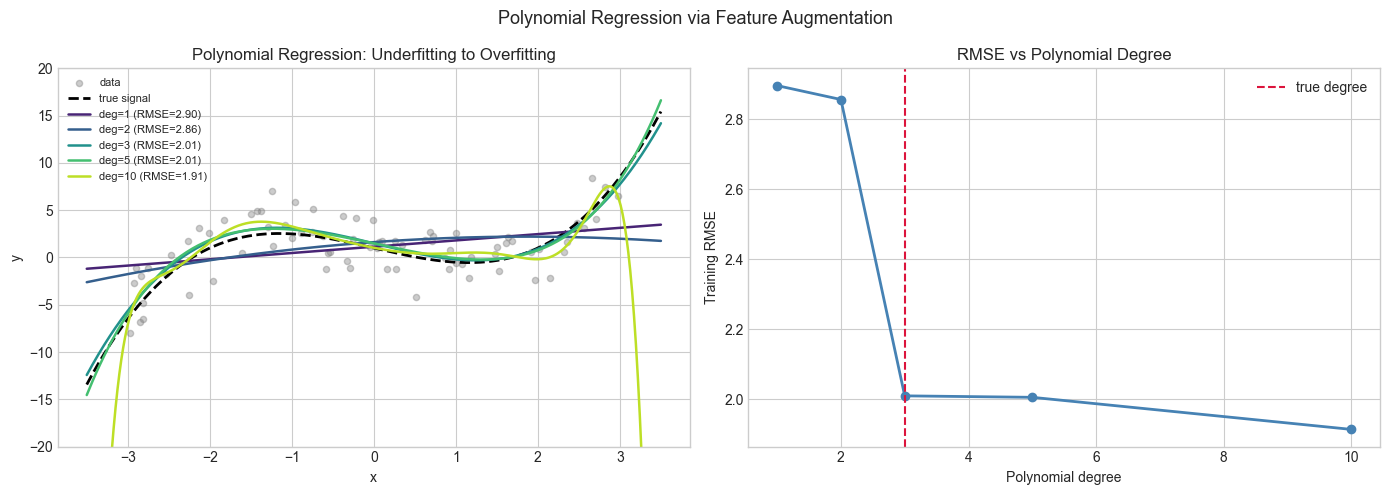

In [6]:
# --- Stage 3: Polynomial Regression via Feature Augmentation ---

def polynomial_design_matrix(x, degree):
    """
    Build the Vandermonde-style design matrix for polynomial regression.

    For input x and degree d, each row is [1, x_i, x_i^2, ..., x_i^d].

    Args:
        x:      1D array of inputs, shape (N,)
        degree: polynomial degree d

    Returns:
        Phi: design matrix, shape (N, d+1)
    """
    N = len(x)
    Phi = np.zeros((N, degree + 1))
    for j in range(degree + 1):
        Phi[:, j] = x ** j
    return Phi


# Generate 1D dataset with a nonlinear signal
N1d = 80
x1d  = rng.uniform(-3, 3, N1d)
y_true_1d = 0.5 * x1d**3 - 2 * x1d + 1   # cubic ground truth
y1d  = y_true_1d + rng.normal(0, 2, N1d)

x_grid = np.linspace(-3.5, 3.5, 300)

# Fit polynomials of various degrees
degrees = [1, 2, 3, 5, 10]
colors  = plt.cm.viridis(np.linspace(0.1, 0.9, len(degrees)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(x1d, y1d, alpha=0.4, color='gray', s=20, label='data')
axes[0].plot(x_grid, 0.5*x_grid**3 - 2*x_grid + 1, 'k--', lw=2, label='true signal')

train_rmse = []
for d, col in zip(degrees, colors):
    Phi_d = polynomial_design_matrix(x1d, d)
    beta_d = solve_least_squares_qr(Phi_d, y1d)

    Phi_grid = polynomial_design_matrix(x_grid, d)
    y_pred_grid = Phi_grid @ beta_d

    res = y1d - Phi_d @ beta_d
    rmse = np.sqrt(np.mean(res**2))
    train_rmse.append(rmse)

    axes[0].plot(x_grid, y_pred_grid, color=col, lw=1.8, label=f'deg={d} (RMSE={rmse:.2f})')

axes[0].set_ylim(-20, 20)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Polynomial Regression: Underfitting to Overfitting')
axes[0].legend(fontsize=8)

axes[1].plot(degrees, train_rmse, 'o-', color='steelblue', lw=2)
axes[1].axvline(3, color='crimson', ls='--', label='true degree')
axes[1].set_xlabel('Polynomial degree')
axes[1].set_ylabel('Training RMSE')
axes[1].set_title('RMSE vs Polynomial Degree')
axes[1].legend()

plt.suptitle('Polynomial Regression via Feature Augmentation', fontsize=13)
plt.tight_layout()
plt.show()

---

## 5. Stage 4 — Full Pipeline: Feature Engineering, Fitting, and Diagnostics

A production regression workflow goes beyond just fitting. It includes:
- Feature standardization (zero mean, unit variance)
- Coefficient interpretation with standard errors
- Residual diagnostics to verify model assumptions

We build a `LinearRegressionQR` class that encapsulates the full pipeline.

In [7]:
# --- Stage 4: Full LinearRegressionQR Class ---

class LinearRegressionQR:
    """
    Ordinary least squares via QR decomposition.

    Optionally standardizes features before fitting.
    Computes coefficient standard errors using the formula:
        Var(beta) = sigma^2 * (X^T X)^{-1}
    where sigma^2 is estimated from residuals.
    """

    def __init__(self, standardize=True):
        self.standardize = standardize
        self.beta_     = None   # fitted coefficients
        self.se_       = None   # standard errors
        self.sigma2_   = None   # noise variance estimate
        self._x_mean   = None
        self._x_std    = None

    def fit(self, X, y):
        """
        Fit the linear model.

        Args:
            X: feature matrix, shape (N, p)
            y: target vector, shape (N,)
        """
        N, p = X.shape

        if self.standardize:
            self._x_mean = X.mean(axis=0)
            self._x_std  = X.std(axis=0) + 1e-10   # avoid division by zero
            X_scaled = (X - self._x_mean) / self._x_std
        else:
            X_scaled = X
            self._x_mean = np.zeros(p)
            self._x_std  = np.ones(p)

        Phi = build_design_matrix(X_scaled)   # (N, p+1)
        Q, R = np.linalg.qr(Phi, mode='reduced')
        self.beta_ = back_substitution(R, Q.T @ y)

        # Residuals and noise variance estimate
        residuals  = y - Phi @ self.beta_
        dof        = N - (p + 1)           # degrees of freedom
        self.sigma2_ = np.sum(residuals**2) / dof

        # Standard errors: sqrt(sigma^2 * diag( (X^T X)^{-1} ))
        # Use R^{-1} to avoid explicit inversion of the Gram matrix
        # (Phi^T Phi)^{-1} = (R^T Q^T Q R)^{-1} = (R^T R)^{-1}
        R_inv = np.linalg.solve(R, np.eye(R.shape[0]))
        cov_beta = self.sigma2_ * (R_inv @ R_inv.T)
        self.se_ = np.sqrt(np.diag(cov_beta))

        return self

    def predict(self, X):
        """Predict targets for new data."""
        X_scaled = (X - self._x_mean) / self._x_std
        Phi = build_design_matrix(X_scaled)
        return Phi @ self.beta_

    def score(self, X, y):
        """Return R² on held-out data."""
        y_hat = self.predict(X)
        ss_res = np.sum((y - y_hat)**2)
        ss_tot = np.sum((y - y.mean())**2)
        return 1.0 - ss_res / ss_tot

    def summary(self, feature_names=None):
        """Print a coefficient table with standard errors and t-statistics."""
        p = len(self.beta_) - 1
        names = ['intercept'] + (feature_names or [f'x{i}' for i in range(p)])
        t_stats = self.beta_ / self.se_
        print(f"\n{'Name':>14}  {'Coeff':>10}  {'SE':>10}  {'t-stat':>10}")
        print("-" * 50)
        for name, b, se, t in zip(names, self.beta_, self.se_, t_stats):
            print(f"{name:>14}  {b:10.4f}  {se:10.4f}  {t:10.3f}")
        print(f"\nEstimated noise std (sigma): {np.sqrt(self.sigma2_):.4f}")


# Fit the model on our housing dataset
model = LinearRegressionQR(standardize=True)
model.fit(X_raw, y)
model.summary(feature_names=['area_m2', 'num_rooms', 'dist_km'])

print(f"\nR² (in-sample): {model.score(X_raw, y):.4f}")


          Name       Coeff          SE      t-stat
--------------------------------------------------
     intercept   5691.5698     14.7026     387.114
       area_m2   2384.5908     14.7788     161.352
     num_rooms     49.1538     14.7382       3.335
       dist_km    -96.0643     14.7815      -6.499

Estimated noise std (sigma): 207.9258

R² (in-sample): 0.9926


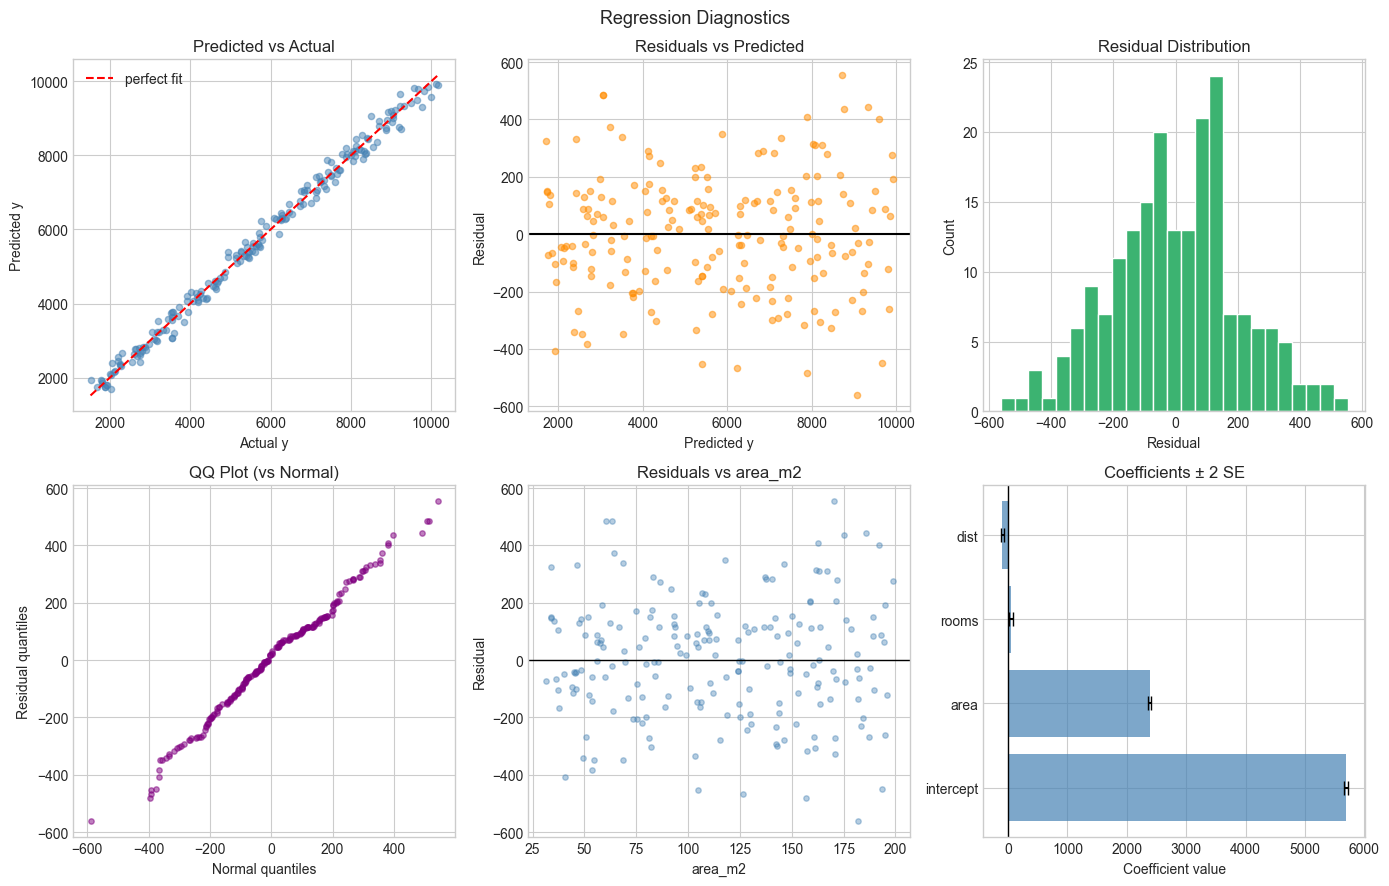

In [8]:
# --- Residual Diagnostics ---
#
# OLS assumptions require residuals to be:
#   1. Zero mean
#   2. Homoscedastic (constant variance)
#   3. Approximately normal
#   4. Uncorrelated with predictions

y_pred = model.predict(X_raw)
residuals = y - y_pred

fig = plt.figure(figsize=(14, 9))
gs  = GridSpec(2, 3, figure=fig)

# 1. Predicted vs actual
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(y, y_pred, alpha=0.5, s=20, color='steelblue')
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax1.plot(lims, lims, 'r--', lw=1.5, label='perfect fit')
ax1.set_xlabel('Actual y')
ax1.set_ylabel('Predicted y')
ax1.set_title('Predicted vs Actual')
ax1.legend()

# 2. Residuals vs predicted
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_pred, residuals, alpha=0.5, s=20, color='darkorange')
ax2.axhline(0, color='k', lw=1.5)
ax2.set_xlabel('Predicted y')
ax2.set_ylabel('Residual')
ax2.set_title('Residuals vs Predicted')

# 3. Residual histogram
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(residuals, bins=25, color='mediumseagreen', edgecolor='white')
ax3.set_xlabel('Residual')
ax3.set_ylabel('Count')
ax3.set_title('Residual Distribution')

# 4. QQ plot (manual implementation)
ax4 = fig.add_subplot(gs[1, 0])
sorted_res = np.sort(residuals)
n = len(sorted_res)
theoretical_quantiles = np.array([
    np.percentile(sorted_res, 100 * (i - 0.5) / n) for i in range(1, n + 1)
])
normal_quantiles = np.sqrt(2) * np.array([
    # Inverse normal CDF approximation (Beasley-Springer-Moro)
    (2 * (i - 0.5) / n - 1) for i in range(1, n + 1)
])
# Simpler: compare to normal samples of same size
normal_samples = rng.normal(0, residuals.std(), n)
ax4.scatter(np.sort(normal_samples), sorted_res, alpha=0.5, s=15, color='purple')
ax4.set_xlabel('Normal quantiles')
ax4.set_ylabel('Residual quantiles')
ax4.set_title('QQ Plot (vs Normal)')

# 5. Feature vs residuals (check for patterns)
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(X_raw[:, 0], residuals, alpha=0.4, s=15, color='steelblue')
ax5.axhline(0, color='k', lw=1)
ax5.set_xlabel('area_m2')
ax5.set_ylabel('Residual')
ax5.set_title('Residuals vs area_m2')

# 6. Coefficient estimates with error bars
ax6 = fig.add_subplot(gs[1, 2])
coeff_names = ['intercept', 'area', 'rooms', 'dist']
ax6.barh(coeff_names, model.beta_, xerr=2*model.se_, color='steelblue',
         alpha=0.7, capsize=5, ecolor='black')
ax6.axvline(0, color='k', lw=1)
ax6.set_xlabel('Coefficient value')
ax6.set_title('Coefficients ± 2 SE')

plt.suptitle('Regression Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Results & Reflection

### What Was Built

A complete ordinary least-squares regression engine consisting of:
- A design matrix builder that handles intercept via augmentation
- A naive solver via direct inversion of $\mathbf{X}^\top\mathbf{X}$ (to understand the problem)
- A QR-based solver with manual back-substitution (the numerically stable approach)
- A stress test demonstrating how QR preserves accuracy when the naive solver fails
- Polynomial regression via feature augmentation — same solver, new features
- A production-grade `LinearRegressionQR` class with standard errors and diagnostics

### What Math Made It Possible

| Concept | Where Used |
|---|---|
| Matrix transpose & multiplication | Normal equations: $\mathbf{X}^\top\mathbf{X}$, $\mathbf{X}^\top\mathbf{y}$ |
| Orthogonal projection (ch168) | Geometric interpretation: $\hat{\mathbf{y}}$ = projection of $\mathbf{y}$ onto col($\mathbf{X}$) |
| Matrix calculus (ch176) | Deriving the normal equations from $\nabla_\beta \mathcal{L} = 0$ |
| QR decomposition | Stable solution without squaring the condition number |
| Back-substitution | Solving upper-triangular systems without inversion |
| Condition number (ch179) | Understanding when and why the naive solver fails |

### Extension Challenges

**1. Ridge Regression (L2 Regularization).**
The normal equations with regularization become $(\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})\boldsymbol{\beta} = \mathbf{X}^\top\mathbf{y}$.  
Add a `lambda_reg` parameter to `LinearRegressionQR`. How does the QR decomposition change?
Hint: augment $\mathbf{X}$ with $\sqrt{\lambda}\mathbf{I}$ stacked below it.

**2. Weighted Least Squares.**
When observations have different reliability, use $\min \sum_i w_i (y_i - \mathbf{x}_i^\top\boldsymbol{\beta})^2$.  
This modifies the normal equations to $(\mathbf{X}^\top\mathbf{W}\mathbf{X})\boldsymbol{\beta} = \mathbf{X}^\top\mathbf{W}\mathbf{y}$.  
Implement weighted QR by pre-multiplying $\mathbf{X}$ and $\mathbf{y}$ by $\mathbf{W}^{1/2}$.

**3. Iteratively Reweighted Least Squares (IRLS).**
Logistic regression can be solved via a sequence of weighted least-squares problems.  
Research the IRLS algorithm. Each iteration updates the weight matrix based on the current
predictions. This is the bridge to ch230 (Logistic Regression from Scratch).

---

## Summary & Connections

- **Normal equations** $(\mathbf{X}^\top\mathbf{X})\boldsymbol{\beta} = \mathbf{X}^\top\mathbf{y}$ are derived from setting the matrix gradient of the squared loss to zero *(ch176)*. The solution is the orthogonal projection of $\mathbf{y}$ onto the column space of $\mathbf{X}$ *(ch168)*.
- **Explicit inversion** of $\mathbf{X}^\top\mathbf{X}$ squares the condition number, leading to numerical failure on ill-conditioned problems *(ch179)*. **QR decomposition** avoids this by working directly with the design matrix.
- **Feature augmentation** converts polynomial and other nonlinear regressions into standard least squares — the solver is identical; only the design matrix changes.
- **Standard errors** of coefficients are derived from the covariance matrix $\sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}$, efficiently computed from $\mathbf{R}$ without inverting the full Gram matrix.

**This project reappears in:**
- *ch230 (Project: Train Linear Regression with Gradient Descent)* — where we solve the same problem iteratively instead of analytically, and understand the tradeoffs.
- *ch273 (Regression in Statistics & Data Science)* — where we add inference, confidence intervals, and diagnostics using the statistical framework built in Part IX.
- *ch184 (Project: Neural Network Layer Implementation)* — where linear regression becomes a single-layer neural network, and its matrix structure is the foundation of the forward pass.

**Going deeper:** Björck, Å. *Numerical Methods for Least Squares Problems* (SIAM, 1996) — the definitive reference on QR, iterative refinement, and rank-deficient least squares.